In [1]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression


In [2]:
X = pd.read_csv("..\\data\\cex4WindDataInterpolated.csv", parse_dates=['t'])
print(X.info())
print(X.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 37941 entries, 0 to 37940
Data columns (total 12 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   t       37941 non-null  datetime64[ns]
 1   toy     37941 non-null  float64       
 2   p       37583 non-null  float64       
 3   Ws1     36645 non-null  float64       
 4   Wd1     36645 non-null  float64       
 5   T1      36645 non-null  float64       
 6   Ws2     36643 non-null  float64       
 7   Wd2     36643 non-null  float64       
 8   T2      36643 non-null  float64       
 9   Ws3     36641 non-null  float64       
 10  Wd3     36641 non-null  float64       
 11  T3      36641 non-null  float64       
dtypes: datetime64[ns](1), float64(11)
memory usage: 3.5 MB
None
                                   t           toy             p  \
count                          37941  37941.000000  37583.000000   
mean   2001-03-01 13:00:00.000000128    173.310703      4.912140   
min   

In [3]:
df = X.copy()

# Lagged power
df["p_lag1"] = df["p"].shift(1)
df["p_lag2"] = df["p"].shift(2)
df["p_lag3"] = df["p"].shift(3)

df["Wd1_rad"] = np.deg2rad(df["Wd1"])
df["sinWd1"] = np.sin(df["Wd1_rad"])
df["cosWd1"] = np.cos(df["Wd1_rad"])

required = [
    "p",
    "p_lag1",
    "p_lag2",
    "p_lag3",
    "Ws1",
    "sinWd1",
    "cosWd1"
]

df.dropna(subset=required, inplace=True)


In [4]:
X_reg = df[["p_lag1", "p_lag2", "Ws1", "sinWd1", "cosWd1"]].values
y = df["p"].values

model = LinearRegression()
model.fit(X_reg, y)

print("Intercept:", model.intercept_)
print("Coefficients:", model.coef_)

df["p_hat"] = model.predict(X_reg)
df["resid"] = df["p"] - df["p_hat"]

Intercept: -0.7088925273738598
Coefficients: [ 1.02644588 -0.19840268  0.18344881 -0.03034026 -0.13523041]


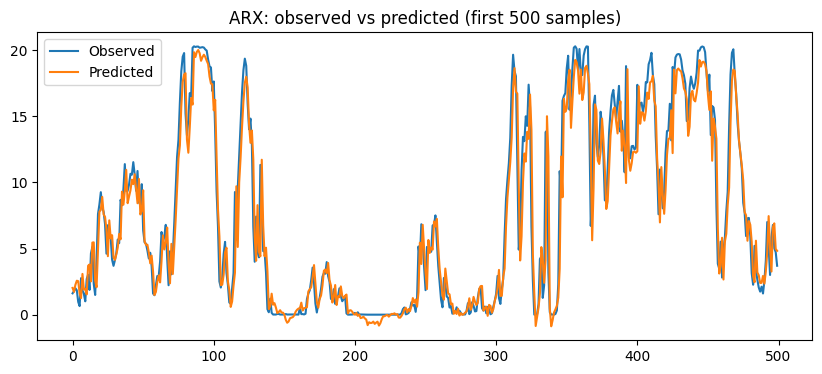

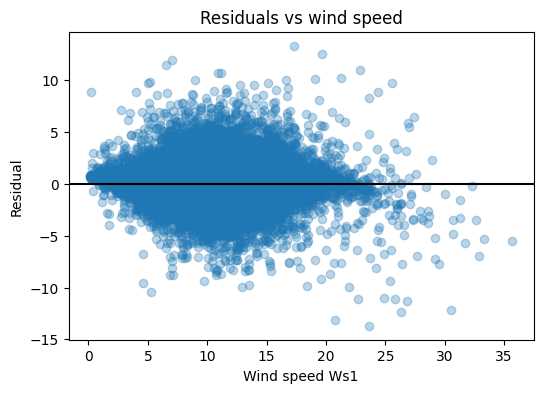

In [5]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 4))
plt.plot(df["p"].values[:500], label="Observed")
plt.plot(df["p_hat"].values[:500], label="Predicted")
plt.legend()
plt.title("ARX: observed vs predicted (first 500 samples)")
plt.show()
plt.figure(figsize=(6, 4))
plt.scatter(df["Ws1"], df["resid"], alpha=0.3)
plt.axhline(0, color="black")
plt.xlabel("Wind speed Ws1")
plt.ylabel("Residual")
plt.title("Residuals vs wind speed")
plt.show()


In [6]:
df2 = df.copy()

# Nonlinear wind speed terms
df2["Ws1_2"] = df2["Ws1"] ** 2
df2["Ws1_3"] = df2["Ws1"] ** 3

# df2["sqrt_p"] = np.sqrt(df2["p"])

X_nl = df2[
    [
        "p_lag1",
        "p_lag2",
        "Ws1",
        "Ws1_2",
        "Ws1_3",
        "sinWd1",
        "cosWd1",
    ]
].values

y = df2["p"].values


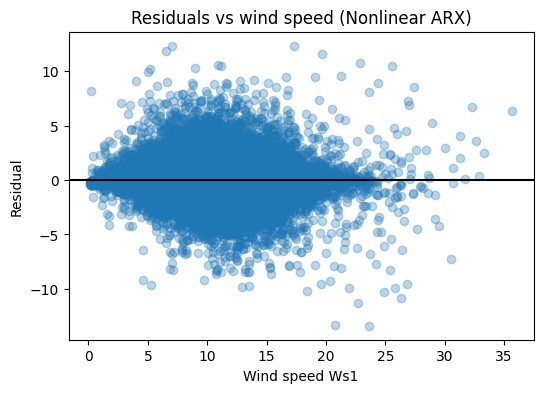

Linear ARX residual variance : 2.436424374163589
Nonlinear ARX residual variance: 2.3723044512715545


In [7]:
from sklearn.linear_model import LinearRegression

model_nl = LinearRegression()
model_nl.fit(X_nl, y)

df2["p_hat_nl"] = model_nl.predict(X_nl)
df2["resid_nl"] = df2["p"] - df2["p_hat_nl"]
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 4))
plt.scatter(df2["Ws1"], df2["resid_nl"], alpha=0.3)
plt.axhline(0, color="black")
plt.xlabel("Wind speed Ws1")
plt.ylabel("Residual")
plt.title("Residuals vs wind speed (Nonlinear ARX)")
plt.show()

print("Linear ARX residual variance :", df["resid"].var())
print("Nonlinear ARX residual variance:", df2["resid_nl"].var())


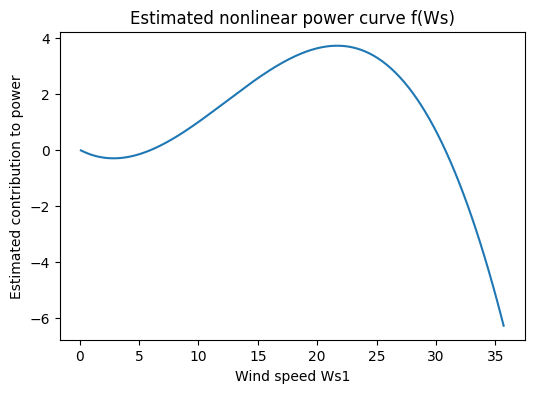

In [8]:
Ws_grid = np.linspace(df["Ws1"].min(), df["Ws1"].max(), 200)

# isolate only the nonlinear Ws part
coef = model_nl.coef_
f_ws = (
    coef[2] * Ws_grid
    + coef[3] * Ws_grid**2
    + coef[4] * Ws_grid**3
)

plt.figure(figsize=(6, 4))
plt.plot(Ws_grid, f_ws)
plt.xlabel("Wind speed Ws1")
plt.ylabel("Estimated contribution to power")
plt.title("Estimated nonlinear power curve f(Ws)")
plt.show()


In [9]:
df3 = df2.copy()

# Hour of day
df3["hour"] = df3["t"].dt.hour

# Diurnal harmonics
df3["sin24"] = np.sin(2 * np.pi * df3["hour"] / 24)
df3["cos24"] = np.cos(2 * np.pi * df3["hour"] / 24)
# Temperature already interpolated
# Centering helps interpretation
df3["T1_c"] = df3["T1"] - df3["T1"].mean()


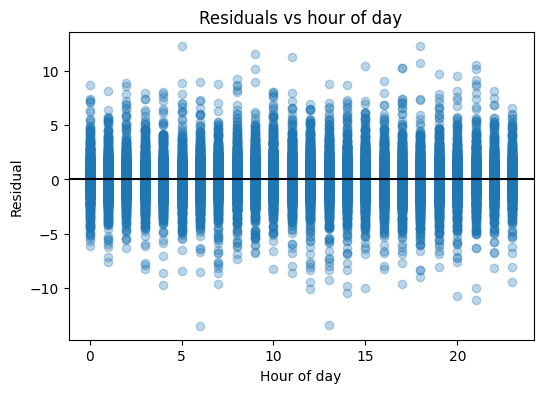

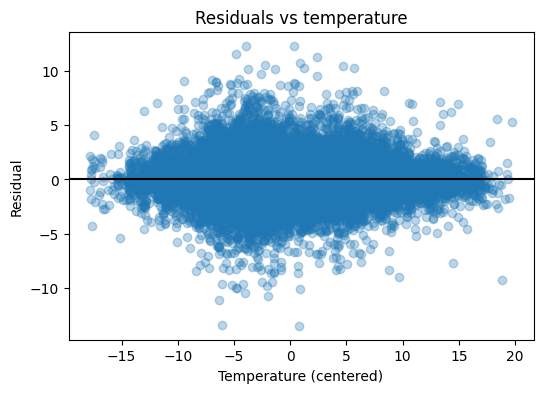

Residual variance (day): 2.535324416506428
Residual variance (night): 2.1379898594605518


In [10]:
X_ext = df3[
    [
        "p_lag1",
        "p_lag2",
        "Ws1",
        "Ws1_2",
        "Ws1_3",
        "sinWd1",
        "cosWd1",
        "sin24",
        "cos24",
        "T1_c",
    ]
].values

y = df3["p"].values
model_ext = LinearRegression()
model_ext.fit(X_ext, y)

df3["p_hat_ext"] = model_ext.predict(X_ext)
df3["resid_ext"] = df3["p"] - df3["p_hat_ext"]

plt.figure(figsize=(6, 4))
plt.scatter(df3["hour"], df3["resid_ext"], alpha=0.3)
plt.axhline(0, color="black")
plt.xlabel("Hour of day")
plt.ylabel("Residual")
plt.title("Residuals vs hour of day")
plt.show()

plt.figure(figsize=(6, 4))
plt.scatter(df3["T1_c"], df3["resid_ext"], alpha=0.3)
plt.axhline(0, color="black")
plt.xlabel("Temperature (centered)")
plt.ylabel("Residual")
plt.title("Residuals vs temperature")
plt.show()

df3["is_night"] = ((df3["hour"] <= 6) | (df3["hour"] >= 20))

print(
    "Residual variance (day):",
    df3.loc[~df3["is_night"], "resid_ext"].var()
)
print(
    "Residual variance (night):",
    df3.loc[df3["is_night"], "resid_ext"].var()
)


In [11]:
for label, mask in {
    "day": ~df3["is_night"],
    "night": df3["is_night"],
}.items():

    model = LinearRegression()
    model.fit(X_ext[mask], y[mask])
    resid = y[mask] - model.predict(X_ext[mask])

    print(label, "residual variance:", resid.var())


day residual variance: 2.525381207931825
night residual variance: 2.1241589511893677


In [12]:
df4 = df3.copy()

# Time indices
df4["hour"] = df4["t"].dt.hour
df4["dow"] = df4["t"].dt.dayofweek          # 0=Mon
df4["doy"] = df4["t"].dt.dayofyear

df4["sin168"] = np.sin(2 * np.pi * (df4["hour"] + 24*df4["dow"]) / 168)
df4["cos168"] = np.cos(2 * np.pi * (df4["hour"] + 24*df4["dow"]) / 168)

df4["sin365"] = np.sin(2 * np.pi * df4["doy"] / 365.25)
df4["cos365"] = np.cos(2 * np.pi * df4["doy"] / 365.25)

X_seas = df4[
    [
        "p_lag1",
        "p_lag2",
        "Ws1",
        "Ws1_2",
        "Ws1_3",
        "sinWd1",
        "cosWd1",
        "sin24",
        "cos24",
        "sin168",
        "cos168",
        "sin365",
        "cos365",
        "T1_c",
    ]
].values

y = df4["p"].values


In [13]:
model_seas = LinearRegression()
model_seas.fit(X_seas, y)

df4["p_hat_seas"] = model_seas.predict(X_seas)
df4["resid_seas"] = df4["p"] - df4["p_hat_seas"]

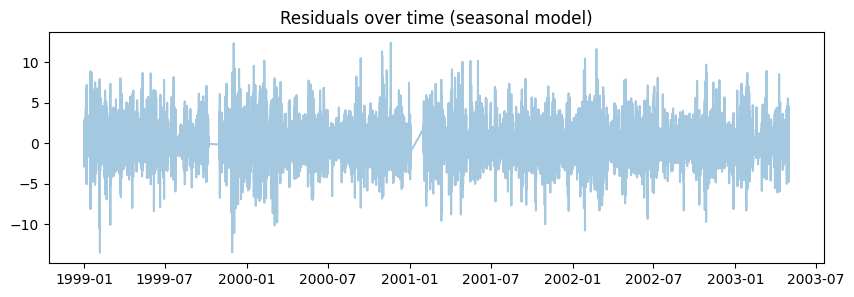

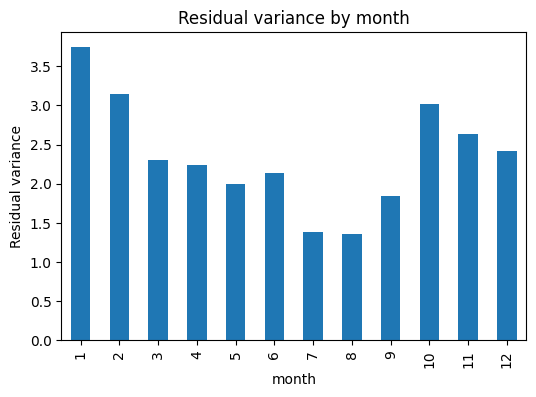

NL ARX variance       : 2.3723044512715545
Seasonal NL ARX var   : 2.346782331141259


In [14]:
plt.figure(figsize=(10, 3))
plt.plot(df4["t"], df4["resid_seas"], alpha=0.4)
plt.title("Residuals over time (seasonal model)")
plt.show()

df4["month"] = df4["t"].dt.month

monthly_var = df4.groupby("month")["resid_seas"].var()

monthly_var.plot(kind="bar", figsize=(6, 4))
plt.ylabel("Residual variance")
plt.title("Residual variance by month")
plt.show()
print("NL ARX variance       :", df2["resid_nl"].var())
print("Seasonal NL ARX var   :", df4["resid_seas"].var())



In [15]:
# Add regime switching based on season

df5 = df4.copy()

# squared residuals as variance proxy
df5["resid2"] = df5["resid_seas"] ** 2
# define seasons
df5["is_winter"] = df5["t"].dt.month.isin([10, 11, 12, 1, 2])
df5["is_summer"] = df5["t"].dt.month.isin([7, 8])
from sklearn.linear_model import LinearRegression

# avoid log(0)
eps = 1e-6

Z_var = df5[
    [
        "is_winter",
        "Ws1",
        "T1_c",
    ]
].values

y_var = np.log(df5["resid2"] + eps)

var_model = LinearRegression()
var_model.fit(Z_var, y_var)

df5["log_var_hat"] = var_model.predict(Z_var)
df5["var_hat"] = np.exp(df5["log_var_hat"])

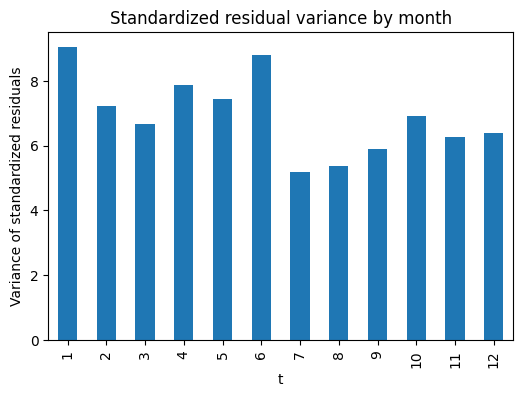

In [16]:
df5["std_resid"] = df5["resid_seas"] / np.sqrt(df5["var_hat"])

monthly_var_std = df5.groupby(df5["t"].dt.month)["std_resid"].var()

monthly_var_std.plot(kind="bar", figsize=(6, 4))
plt.ylabel("Variance of standardized residuals")
plt.title("Standardized residual variance by month")
plt.show()

In [17]:
df6 = df5.copy()

df6["sin365"] = np.sin(2 * np.pi * df6["t"].dt.dayofyear / 365.25)
df6["cos365"] = np.cos(2 * np.pi * df6["t"].dt.dayofyear / 365.25)

Z_var2 = df6[
    [
        "Ws1",
        "T1_c",
        "sin365",
        "cos365",
    ]
].values

y_var = np.log(df6["resid2"] + 1e-6)

var_model2 = LinearRegression()
var_model2.fit(Z_var2, y_var)

df6["log_var_hat2"] = var_model2.predict(Z_var2)
df6["var_hat2"] = np.exp(df6["log_var_hat2"])


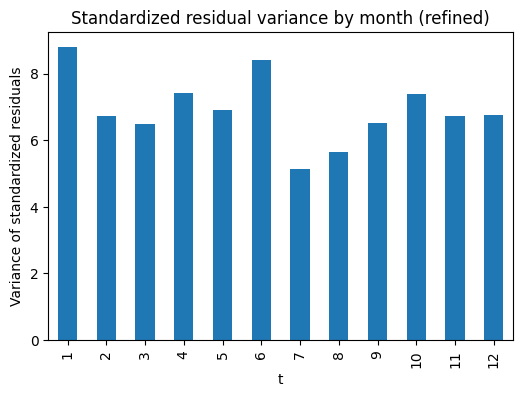

In [18]:
df6["std_resid2"] = df6["resid_seas"] / np.sqrt(df6["var_hat2"])

monthly_var_std2 = df6.groupby(df6["t"].dt.month)["std_resid2"].var()

monthly_var_std2.plot(kind="bar", figsize=(6, 4))
plt.ylabel("Variance of standardized residuals")
plt.title("Standardized residual variance by month (refined)")
plt.show()


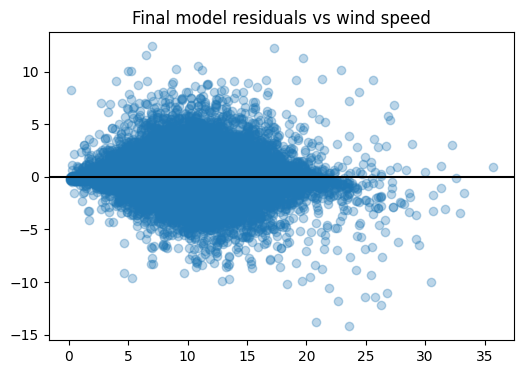

In [19]:
weights = 1 / df6["var_hat2"]

model_final = LinearRegression()
model_final.fit(X_seas, y, sample_weight=weights)

df6["p_hat_final"] = model_final.predict(X_seas)
df6["resid_final"] = df6["p"] - df6["p_hat_final"]
plt.figure(figsize=(6, 4))
plt.scatter(df6["Ws1"], df6["resid_final"], alpha=0.3)
plt.axhline(0, color="black")
plt.title("Final model residuals vs wind speed")
plt.show()
